In [2]:
"""
PV Module Single-Diode Simulation from EL-Extracted Rs and J0
=============================================================
Uses pvlib to simulate I-V curves from Rajput-method parameters
and overlays with measured flash I-V data.

Unit conversions (pixel → physical):
  I0 [A]  = J0_module_avg [A/pixel] × N_pixels_per_cell
  Rs [Ω]  = Rs_module_total [Ω·pixel] / N_pixels_per_cell
  Rsh [Ω] = N_cells × Rsh_cell  (Rsh_cell assumed 1000 Ω)
  nNsVth  = n × N_cells × kT/q  (n=1, T=25°C → kT/q=0.02585 V)
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pvlib
import traceback
import time


# ──────────────────────────────────────────────────────────
# 1. MERGE module_summary with AnonDB
# ──────────────────────────────────────────────────────────
def prepare_merged_dataset(
    module_summary_csv,
    anondb_csv,
    output_csv="merged_for_simulation.csv"
):
    """
    Merge module_summary (Rs, J0) with AnonDB (Isc, Voc, IVPath, etc.)
    """
    mod = pd.read_csv(module_summary_csv)
    anon = pd.read_csv(anondb_csv)

    # only OK modules
    mod = mod[mod["status"] == "ok"].copy()

    # extract module base name from AnonDB ELLPath
    anon["ell_base"] = anon["ELLPath"].apply(
        lambda x: str(x).replace(".tiff", "").replace("_wrp", "").split("/")[-1].rsplit("_", 1)[0]
        if pd.notna(x) else ""
    )

    merged = mod.merge(anon, left_on="module", right_on="ell_base", how="inner")

    # compute physical parameters
    merged["N_pix_per_cell"] = merged["vals_size"] / merged["n_cells"]
    merged["I0_A"]   = merged["J0_module_avg"] * merged["N_pix_per_cell"]
    merged["Rs_Ohm"] = merged["Rs_module_total"] / merged["N_pix_per_cell"]
    merged["Rsh_Ohm"] = merged["n_cells"] * 1000.0   # 1000 Ω per cell
    merged["nNsVth"] = 1.0 * merged["n_cells"] * 0.02585  # n=1, T=25°C
    merged["IL_A"]   = merged["Isc_(A)"]

    merged.to_csv(output_csv, index=False)
    print(f"Merged dataset: {len(merged)} modules → {output_csv}")
    return merged


# ──────────────────────────────────────────────────────────
# 2. SIMULATE single-diode for all modules
# ──────────────────────────────────────────────────────────
def simulate_all_modules(
    merged_df,
    output_csv="simulated_iv_results.csv"
):
    """
    Run pvlib.pvsystem.singlediode for each module.
    Returns DataFrame with simulated + measured performance params.
    """
    results = []

    for idx, row in merged_df.iterrows():
        mod_name = row["module"]

        try:
            sim = pvlib.pvsystem.singlediode(
                photocurrent=row["IL_A"],
                saturation_current=row["I0_A"],
                resistance_series=row["Rs_Ohm"],
                resistance_shunt=row["Rsh_Ohm"],
                nNsVth=row["nNsVth"]
            )

            results.append({
                "module": mod_name,
                # --- measured ---
                "Isc_meas": row["Isc_(A)"],
                "Voc_meas": row["Voc_(V)"],
                "Imp_meas": row["Imp_(A)"],
                "Vmp_meas": row["Vmp_(V)"],
                "Pmp_meas": row["Pmp_(W)"],
                "FF_meas":  row["FF_(percent)"],
                # --- simulated ---
                "Isc_sim": sim["i_sc"],
                "Voc_sim": sim["v_oc"],
                "Imp_sim": sim["i_mp"],
                "Vmp_sim": sim["v_mp"],
                "Pmp_sim": sim["p_mp"],
                "FF_sim":  sim["p_mp"] / (sim["i_sc"] * sim["v_oc"]) * 100,
                # --- input parameters ---
                "I0_A":    row["I0_A"],
                "Rs_Ohm":  row["Rs_Ohm"],
                "Rsh_Ohm": row["Rsh_Ohm"],
                "nNsVth":  row["nNsVth"],
                "IL_A":    row["IL_A"],
                # --- errors ---
                "Voc_err_pct": (sim["v_oc"] - row["Voc_(V)"]) / row["Voc_(V)"] * 100,
                "Pmp_err_pct": (sim["p_mp"] - row["Pmp_(W)"]) / row["Pmp_(W)"] * 100,
                "FF_err_pct":  (sim["p_mp"] / (sim["i_sc"] * sim["v_oc"]) * 100 - row["FF_(percent)"]) / row["FF_(percent)"] * 100,
                # --- paths ---
                "IVPath": row.get("IVPath", ""),
                "status": "ok"
            })

        except Exception as e:
            print(f"  ERROR {mod_name}: {e}")
            results.append({
                "module": mod_name,
                "status": str(e)
            })

    results_df = pd.DataFrame(results)
    results_df.to_csv(output_csv, index=False)

    ok = results_df[results_df["status"] == "ok"]
    print(f"\nSimulation complete: {len(ok)}/{len(results_df)} OK → {output_csv}")
    if len(ok) > 0:
        print(f"\n  Voc error:  mean={ok['Voc_err_pct'].mean():.2f}%, std={ok['Voc_err_pct'].std():.2f}%")
        print(f"  Pmp error:  mean={ok['Pmp_err_pct'].mean():.2f}%, std={ok['Pmp_err_pct'].std():.2f}%")
        print(f"  FF  error:  mean={ok['FF_err_pct'].mean():.2f}%, std={ok['FF_err_pct'].std():.2f}%")

    return results_df


# ──────────────────────────────────────────────────────────
# 3. LOAD measured IV curve from CSV
# ──────────────────────────────────────────────────────────
def load_measured_iv(iv_path):
    """
    Load measured I-V data from CSV.
    Tries common column name patterns.
    """
    df = pd.read_csv(iv_path)

    # try to find voltage and current columns
    v_col = None
    i_col = None
    for c in df.columns:
        cl = c.lower().strip()
        if cl in ("voltage", "v", "voltage (v)", "voltage_(v)", "v(v)"):
            v_col = c
        elif cl in ("current", "i", "current (a)", "current_(a)", "i(a)"):
            i_col = c

    # fallback: first two numeric columns
    if v_col is None or i_col is None:
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if len(num_cols) >= 2:
            v_col, i_col = num_cols[0], num_cols[1]
        else:
            raise ValueError(f"Cannot identify V/I columns in {iv_path}: {df.columns.tolist()}")

    return df[v_col].values, df[i_col].values


# ──────────────────────────────────────────────────────────
# 4. GENERATE simulated IV curve points
# ──────────────────────────────────────────────────────────
def generate_simulated_iv(row, n_points=300):
    """
    Generate V, I arrays for the simulated IV curve.
    """
    v_oc = pvlib.pvsystem.singlediode(
        photocurrent=row["IL_A"],
        saturation_current=row["I0_A"],
        resistance_series=row["Rs_Ohm"],
        resistance_shunt=row["Rsh_Ohm"],
        nNsVth=row["nNsVth"]
    )["v_oc"]

    v_arr = np.linspace(0, v_oc * 1.02, n_points)
    i_arr = pvlib.pvsystem.i_from_v(
        voltage=v_arr,
        photocurrent=row["IL_A"],
        saturation_current=row["I0_A"],
        resistance_series=row["Rs_Ohm"],
        resistance_shunt=row["Rsh_Ohm"],
        nNsVth=row["nNsVth"]
    )
    # clip negative currents
    i_arr = np.maximum(i_arr, 0)
    return v_arr, i_arr


# ──────────────────────────────────────────────────────────
# 5. PLOT: overlay simulated vs measured IV
# ──────────────────────────────────────────────────────────
def plot_iv_overlay_single(row, base_dir=".", save_path=None):
    """
    Plot a single module: simulated IV + measured IV overlaid.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- simulated ---
    v_sim, i_sim = generate_simulated_iv(row)
    p_sim = v_sim * i_sim

    ax1.plot(v_sim, i_sim, "b-", linewidth=2, label="Simulated (EL)")
    ax2.plot(v_sim, p_sim, "b-", linewidth=2, label="Simulated (EL)")

    # --- measured ---
    iv_path = os.path.normpath(os.path.join(base_dir, row["IVPath"]))
    if os.path.isfile(iv_path):
        try:
            v_meas, i_meas = load_measured_iv(iv_path)
            p_meas = v_meas * i_meas
            ax1.plot(v_meas, i_meas, "r--", linewidth=1.5, label="Measured (Flash)")
            ax2.plot(v_meas, p_meas, "r--", linewidth=1.5, label="Measured (Flash)")
        except Exception as e:
            print(f"  Could not load measured IV: {e}")
    else:
        print(f"  IV file not found: {iv_path}")

    # --- MPP markers ---
    ax1.plot(row["Vmp_sim"], row["Imp_sim"], "bs", markersize=8, label=f"MPP sim ({row['Pmp_sim']:.1f}W)")
    ax2.plot(row["Vmp_sim"], row["Pmp_sim"], "bs", markersize=8)

    if pd.notna(row.get("Vmp_meas")) and pd.notna(row.get("Imp_meas")):
        ax1.plot(row["Vmp_meas"], row["Imp_meas"], "r^", markersize=8, label=f"MPP meas ({row['Pmp_meas']:.1f}W)")
        ax2.plot(row["Vmp_meas"], row["Pmp_meas"], "r^", markersize=8)

    mod = row["module"]
    ax1.set_xlabel("Voltage (V)")
    ax1.set_ylabel("Current (A)")
    ax1.set_title(f"{mod} — I-V Curve")
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, None)
    ax1.set_ylim(0, None)

    ax2.set_xlabel("Voltage (V)")
    ax2.set_ylabel("Power (W)")
    ax2.set_title(f"{mod} — P-V Curve")
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, None)
    ax2.set_ylim(0, None)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close()
    else:
        plt.show()


def plot_iv_overlay_batch(
    results_df,
    base_dir=".",
    save_dir=None,
    max_plots=None
):
    """
    Plot IV overlays for all modules.
    If save_dir is set, saves PNG files instead of displaying.
    """
    ok = results_df[results_df["status"] == "ok"]
    if max_plots:
        ok = ok.head(max_plots)

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    for idx, row in ok.iterrows():
        save_path = os.path.join(save_dir, f"{row['module']}_IV.png") if save_dir else None
        print(f"  Plotting {row['module']}...")
        plot_iv_overlay_single(row, base_dir=base_dir, save_path=save_path)

    print(f"Done! {len(ok)} plots generated.")


# ──────────────────────────────────────────────────────────
# 6. PLOT: summary comparison scatter plots
# ──────────────────────────────────────────────────────────
def plot_summary_scatter(results_df, save_path=None):
    """
    4-panel scatter: Voc, Isc, Pmp, FF (measured vs simulated)
    """
    ok = results_df[results_df["status"] == "ok"].copy()

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    params = [
        ("Voc_meas", "Voc_sim", "Voc (V)", axes[0, 0]),
        ("Pmp_meas", "Pmp_sim", "Pmp (W)", axes[0, 1]),
        ("Imp_meas", "Imp_sim", "Imp (A)", axes[1, 0]),
        ("FF_meas",  "FF_sim",  "FF (%)",  axes[1, 1]),
    ]

    for meas_col, sim_col, label, ax in params:
        x = ok[meas_col]
        y = ok[sim_col]

        ax.scatter(x, y, alpha=0.5, s=20, edgecolors="k", linewidth=0.3)

        # 1:1 line
        lo = min(x.min(), y.min()) * 0.98
        hi = max(x.max(), y.max()) * 1.02
        ax.plot([lo, hi], [lo, hi], "r--", linewidth=1, label="1:1")

        # stats
        from scipy import stats
        slope, intercept, r, p, se = stats.linregress(x, y)
        mae = np.mean(np.abs(y - x))
        ax.set_title(f"{label}  |  R²={r**2:.3f}  MAE={mae:.2f}", fontsize=11)
        ax.set_xlabel(f"Measured {label}")
        ax.set_ylabel(f"Simulated {label}")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle("Simulated (EL single-diode) vs Measured (Flash I-V)", fontsize=13, y=1.01)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close()
    else:
        plt.show()


# ──────────────────────────────────────────────────────────
# MAIN: run everything
# ──────────────────────────────────────────────────────────
if __name__ == "__main__":

    BASE_DIR = r"C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding"

    # Step 1: merge datasets
    merged = prepare_merged_dataset(
        module_summary_csv="module_summary.csv",
        anondb_csv="AnonDB_zub_60.csv",
        output_csv="merged_for_simulation2.csv"
    )

    # Step 2: simulate all modules
    results = simulate_all_modules(
        merged,
        output_csv="simulated_iv_results2.csv"
    )

    # Step 3: summary scatter plots
    plot_summary_scatter(results, save_path="sim_vs_meas_scatter2.png")

    # Step 4: overlay IV curves (first 10, or all)
    plot_iv_overlay_batch(
        results,
        base_dir=BASE_DIR,
        save_dir="IV_overlay_plots2",
        max_plots=10          # set to None for all
    )

Merged dataset: 274 modules → merged_for_simulation2.csv

Simulation complete: 274/274 OK → simulated_iv_results2.csv

  Voc error:  mean=0.05%, std=1.48%
  Pmp error:  mean=2.72%, std=3.65%
  FF  error:  mean=2.66%, std=3.15%
  Plotting 3855_17_1_01302020...
  Plotting 3857_17_1_02222021...
  Plotting 3857_17_1_01302020...
  Plotting 3858_17_1_02222021...
  Plotting 3859_17_1_02222021...
  Plotting 3859_17_1_01302020...
  Plotting 3865_17_1_02222021...
  Plotting 3865_17_1_01302020...
  Plotting 3866_17_1_02222021...
  Plotting 3866_17_1_01302020...
Done! 10 plots generated.


In [3]:
def plot_iv_overlay_for_module(
    results_df,
    module_name,
    base_dir=".",
    save_dir=None,
    show=True
):
    """
    Plot IV overlay untuk satu module tertentu.
    
    Parameters
    ----------
    results_df : pd.DataFrame
        DataFrame hasil simulasi.
    module_name : str
        Nama module yang ingin diplot. Harus sesuai dengan kolom 'module'.
    base_dir : str
        Folder dasar untuk membaca file IV.
    save_dir : str or None
        Jika diisi, plot akan disimpan sebagai PNG.
    show : bool
        Jika True, plot ditampilkan.
    """

    # Ambil hanya hasil yang status-nya ok
    ok = results_df[results_df["status"].astype(str).str.lower() == "ok"].copy()

    # Filter module tertentu
    selected = ok[ok["module"].astype(str) == str(module_name)]

    if selected.empty:
        raise ValueError(f"Module tidak ditemukan atau status-nya bukan ok: {module_name}")

    # Kalau ternyata ada duplikat, ambil yang pertama
    row = selected.iloc[0]

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f"{row['module']}_IV.png")
    else:
        save_path = None

    print(f"Plotting {row['module']}...")

    plot_iv_overlay_single(
        row,
        base_dir=base_dir,
        save_path=save_path
    )

    print("Done!")

    if save_path:
        print(f"Saved to: {save_path}")

In [8]:
plot_iv_overlay_for_module(
    results,
    module_name="10084_35_1_02222021",
    base_dir=".",
    save_dir="iv_overlay_plots"
)

Plotting 10084_35_1_02222021...
Done!
Saved to: iv_overlay_plots\10084_35_1_02222021_IV.png


Using metadata CSV: AnonDB_80_10_10_seed42.csv
Simulation rows with status='ok': 274 / 274
Metadata duplicate IVPath rows removed: 3
Valid merged PVLIB baseline rows: 274 / 274

Split counts:
split
train    215.0
val       29.0
test      30.0
all        NaN
Name: count, dtype: float64

Make by split:
split      test  train  val
make_plot                  
15            4     20    3
17            5     37    5
20            5     37    5
24            5     35    5
25            6     44    6
34            1     14    2
35            3     21    3
38            1      7    0

Important PVLIB baseline metrics:
    Target   Group Group_value   N       MAE      RMSE         R2      Bias  Unit
   PF_Pmpp overall     overall 274  0.037549  0.044564  -3.713326  0.026887 ratio
   PF_Pmpp   split        test  30  0.033579  0.040517  -3.606465  0.033430 ratio
   PF_Pmpp   split       train 215  0.037724  0.044498  -3.557155  0.025470 ratio
   PF_Pmpp   split         val  29  0.040358  0.048844 

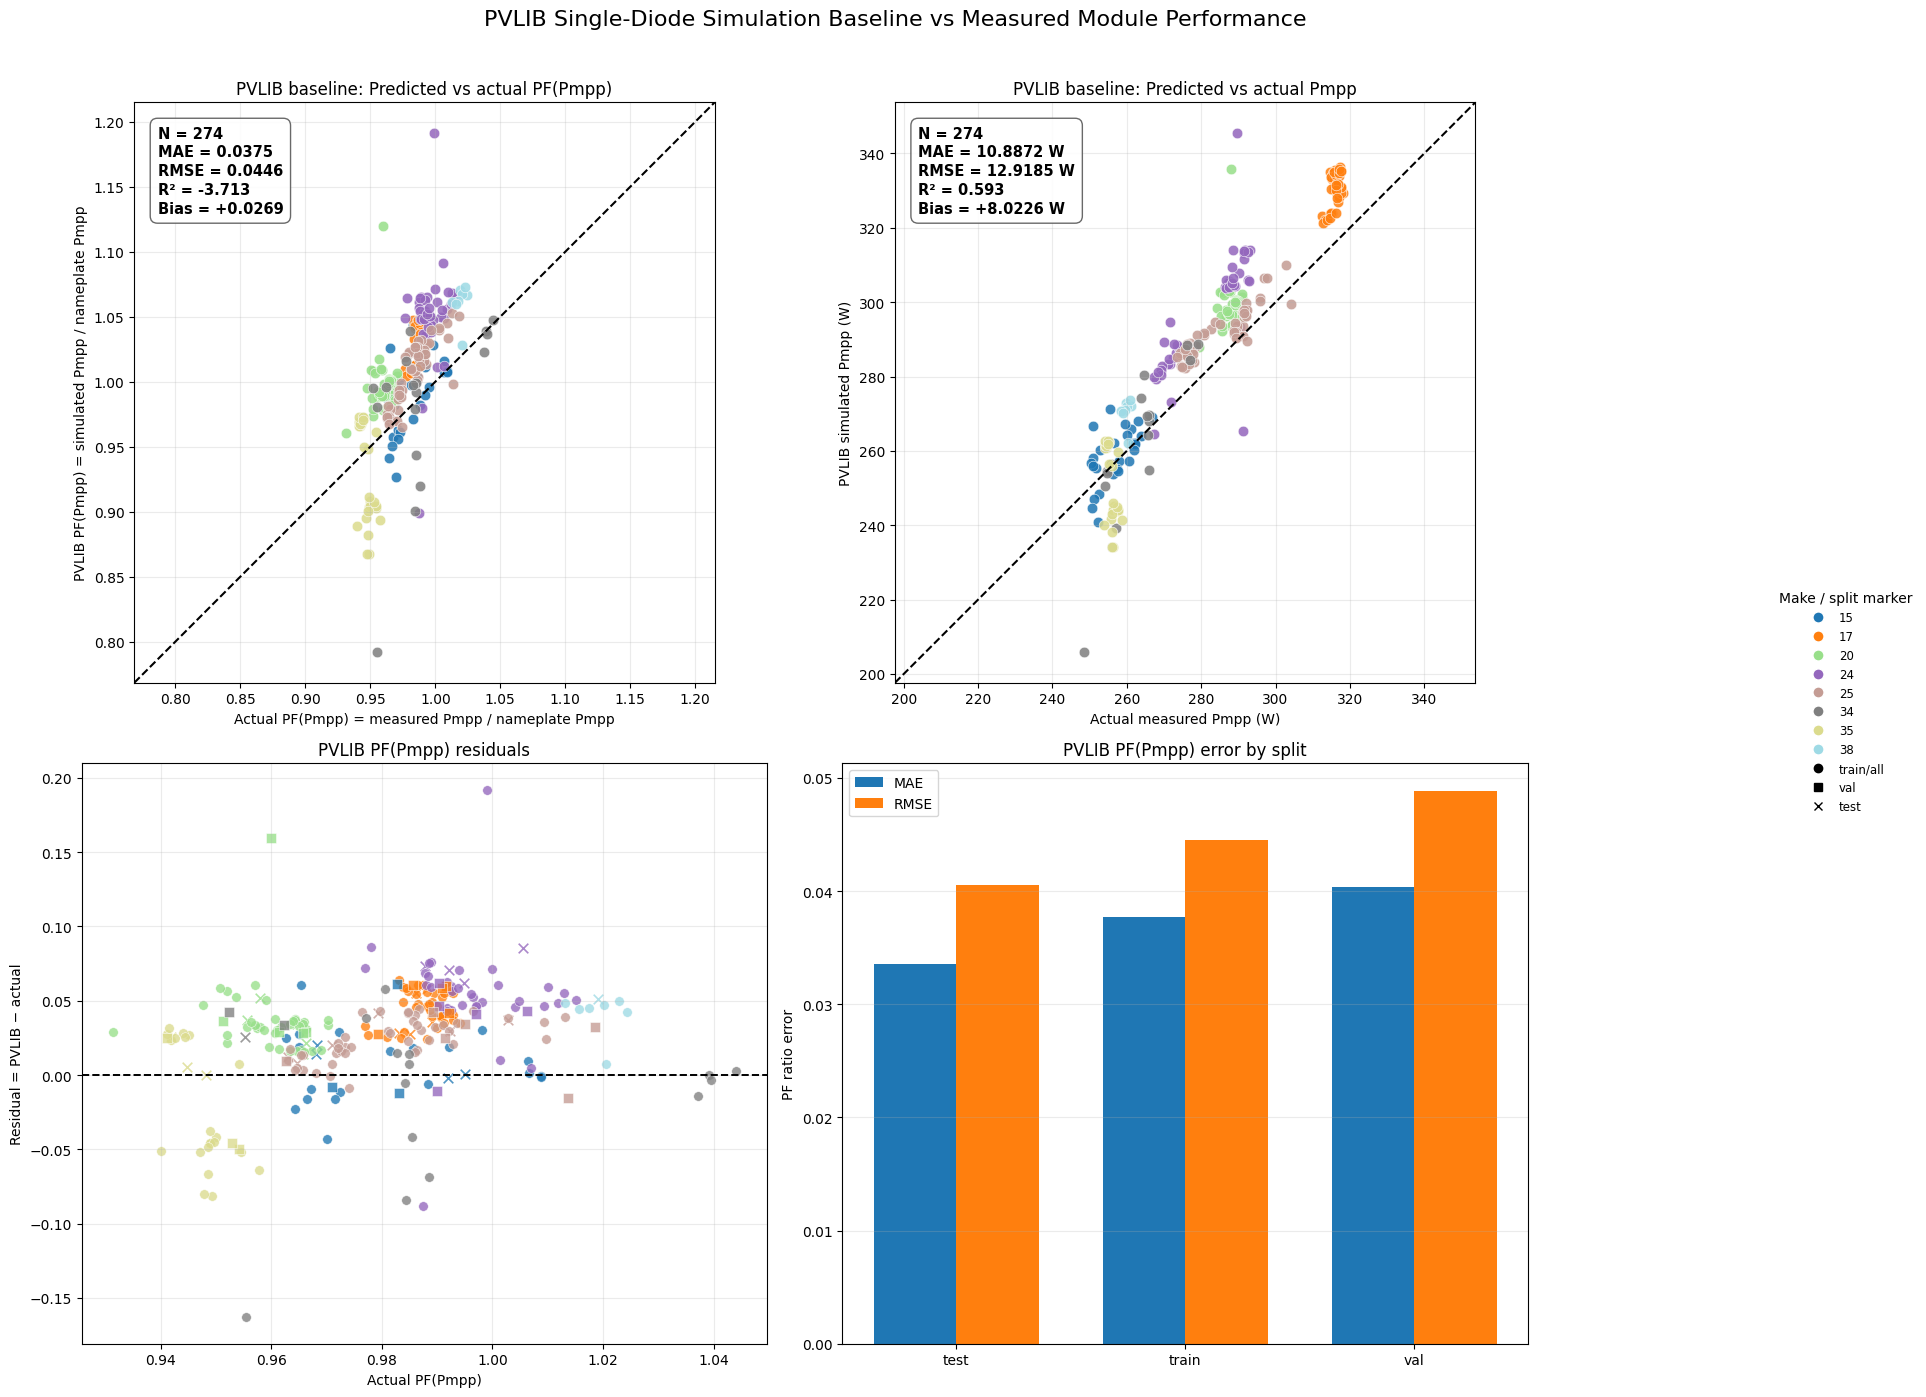


Saved:
- pvlib_baseline_predictions.csv
- pvlib_baseline_metrics.csv
- pvlib_baseline_comparison_curves.png

Main comparison target for ML:
actual_pf_pmp = Pmp_meas / Nameplate_Pmp_(W)
pvlib_pf_pmp = Pmp_sim / Nameplate_Pmp_(W)


In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =========================================================
# CONFIG
# =========================================================
SIM_CSV_PATH = "simulated_iv_results.csv"

# Use the fixed-split CSV if you want a fair comparison with ML.
# If this file is not found, the script will fall back to AnonDB.csv
# and use one split called "all".
METADATA_CSV_PATH = "AnonDB_80_10_10_seed42.csv"
FALLBACK_METADATA_CSV_PATH = "AnonDB.csv"

MAKE_COLUMN = "Make"
MODEL_COLUMN = "Model"
SPLIT_COLUMN = "split"

OUTPUT_PREFIX = "pvlib_baseline"


# =========================================================
# BASIC HELPERS
# =========================================================
def normalise_path(path_value):
    """Normalise relative paths so ./IV/a.csv and IV\\a.csv match."""
    if pd.isna(path_value):
        return None
    return str(path_value).strip().replace("\\", "/").lstrip("./").lower()


def choose_existing_metadata_path():
    if os.path.exists(METADATA_CSV_PATH):
        print(f"Using metadata CSV: {METADATA_CSV_PATH}")
        return METADATA_CSV_PATH

    if os.path.exists(FALLBACK_METADATA_CSV_PATH):
        print(
            f"Warning: {METADATA_CSV_PATH} was not found. "
            f"Using fallback metadata CSV: {FALLBACK_METADATA_CSV_PATH}"
        )
        return FALLBACK_METADATA_CSV_PATH

    raise FileNotFoundError(
        f"Neither {METADATA_CSV_PATH} nor {FALLBACK_METADATA_CSV_PATH} was found."
    )


def safe_numeric(series):
    return pd.to_numeric(series, errors="coerce")


# =========================================================
# DATA PREPARATION
# =========================================================
def load_metadata(metadata_csv_path):
    df = pd.read_csv(metadata_csv_path)

    required_cols = [
        "IVPath",
        MAKE_COLUMN,
        MODEL_COLUMN,
        "Nameplate_Pmp_(W)",
        "Pmp_(W)",
        "Voc_(V)",
        "Isc_(A)",
        "Vmp_(V)",
        "Imp_(A)",
        "FF_(percent)",
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required metadata column: {col}")

    if SPLIT_COLUMN not in df.columns:
        print(
            f"Warning: metadata CSV has no '{SPLIT_COLUMN}' column. "
            "All rows will be assigned to split='all'."
        )
        df[SPLIT_COLUMN] = "all"

    df["join_key"] = df["IVPath"].apply(normalise_path)

    # Convert measured columns to numeric
    numeric_cols = [
        "Nameplate_Pmp_(W)",
        "Pmp_(W)",
        "Voc_(V)",
        "Isc_(A)",
        "Vmp_(V)",
        "Imp_(A)",
        "FF_(percent)",
    ]
    for col in numeric_cols:
        df[col] = safe_numeric(df[col])

    # Some IVPath values can appear more than once in AnonDB.csv.
    # Prefer rows with ELHPath available, then keep the first.
    if "ELHPath" in df.columns:
        df["has_elh"] = df["ELHPath"].notna().astype(int)
        df = df.sort_values(["join_key", "has_elh"], ascending=[True, False])

    before = len(df)
    df = df.drop_duplicates(subset="join_key", keep="first").copy()
    after = len(df)

    if before != after:
        print(f"Metadata duplicate IVPath rows removed: {before - after}")

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)
    df["model_plot"] = df[MODEL_COLUMN].fillna("Unknown").astype(str)
    df[SPLIT_COLUMN] = df[SPLIT_COLUMN].astype(str).str.strip().str.lower()

    return df


def load_simulation(sim_csv_path):
    sim = pd.read_csv(sim_csv_path)

    required_cols = [
        "IVPath",
        "Pmp_meas",
        "Voc_meas",
        "Isc_meas",
        "Vmp_meas",
        "Imp_meas",
        "FF_meas",
        "Pmp_sim",
        "Voc_sim",
        "Isc_sim",
        "Vmp_sim",
        "Imp_sim",
        "FF_sim",
    ]

    for col in required_cols:
        if col not in sim.columns:
            raise ValueError(f"Missing required simulation column: {col}")

    if "status" in sim.columns:
        before = len(sim)
        sim = sim[sim["status"].astype(str).str.lower().eq("ok")].copy()
        print(f"Simulation rows with status='ok': {len(sim)} / {before}")

    sim["join_key"] = sim["IVPath"].apply(normalise_path)

    numeric_cols = [
        "Pmp_meas",
        "Voc_meas",
        "Isc_meas",
        "Vmp_meas",
        "Imp_meas",
        "FF_meas",
        "Pmp_sim",
        "Voc_sim",
        "Isc_sim",
        "Vmp_sim",
        "Imp_sim",
        "FF_sim",
    ]
    for col in numeric_cols:
        sim[col] = safe_numeric(sim[col])

    before = len(sim)
    sim = sim.drop_duplicates(subset="join_key", keep="first").copy()
    after = len(sim)
    if before != after:
        print(f"Simulation duplicate IVPath rows removed: {before - after}")

    return sim


def prepare_pvlib_baseline_dataframe(sim_csv_path, metadata_csv_path):
    sim = load_simulation(sim_csv_path)
    meta = load_metadata(metadata_csv_path)

    meta_cols = [
        "join_key",
        MAKE_COLUMN,
        MODEL_COLUMN,
        "make_plot",
        "model_plot",
        SPLIT_COLUMN,
        "Nameplate_Pmp_(W)",
        "Pmp_(W)",
        "Voc_(V)",
        "Isc_(A)",
        "Vmp_(V)",
        "Imp_(A)",
        "FF_(percent)",
    ]

    if "Mod_ID" in meta.columns:
        meta_cols.append("Mod_ID")

    merged = sim.merge(
        meta[meta_cols],
        on="join_key",
        how="left",
        validate="one_to_one",
        indicator=True,
    )

    missing_meta = (merged["_merge"] != "both").sum()
    if missing_meta:
        print(f"Warning: {missing_meta} simulation rows could not be matched to metadata.")

    merged = merged[merged["_merge"] == "both"].copy()
    merged = merged.drop(columns=["_merge"])

    # Actual measured values from simulation CSV are used because those are the
    # paired measured values for the simulated IV results. Metadata values are
    # kept for checking and nameplate normalization.
    merged["actual_pmp_w"] = merged["Pmp_meas"]
    merged["pvlib_pmp_w"] = merged["Pmp_sim"]

    merged["nameplate_pmp_w"] = merged["Nameplate_Pmp_(W)"]

    # Performance factor for Pmpp, equivalent to the ML target:
    # measured/simulated Pmpp divided by nameplate Pmpp.
    merged["actual_pf_pmp"] = merged["actual_pmp_w"] / merged["nameplate_pmp_w"]
    merged["pvlib_pf_pmp"] = merged["pvlib_pmp_w"] / merged["nameplate_pmp_w"]

    merged["residual_pf_pmp"] = merged["pvlib_pf_pmp"] - merged["actual_pf_pmp"]
    merged["abs_error_pf_pmp"] = np.abs(merged["residual_pf_pmp"])

    merged["residual_pmp_w"] = merged["pvlib_pmp_w"] - merged["actual_pmp_w"]
    merged["abs_error_pmp_w"] = np.abs(merged["residual_pmp_w"])

    # Clean invalid rows
    valid = (
        merged["nameplate_pmp_w"].notna()
        & (merged["nameplate_pmp_w"] > 0)
        & merged["actual_pf_pmp"].notna()
        & merged["pvlib_pf_pmp"].notna()
    )
    before = len(merged)
    merged = merged[valid].copy()
    print(f"Valid merged PVLIB baseline rows: {len(merged)} / {before}")

    return merged.reset_index(drop=True)


# =========================================================
# METRICS
# =========================================================
def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mask = np.isfinite(actual) & np.isfinite(predicted)
    actual = actual[mask]
    predicted = predicted[mask]

    if len(actual) == 0:
        return {
            "N": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "R2": np.nan,
            "Bias": np.nan,
        }

    return {
        "N": len(actual),
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted) if len(actual) >= 2 else np.nan,
        "Bias": float(np.mean(predicted - actual)),
    }


def build_metrics_tables(df):
    metric_pairs = [
        ("PF_Pmpp", "actual_pf_pmp", "pvlib_pf_pmp", "ratio"),
        ("Pmpp_W", "actual_pmp_w", "pvlib_pmp_w", "W"),
        ("Voc_V", "Voc_meas", "Voc_sim", "V"),
        ("Isc_A", "Isc_meas", "Isc_sim", "A"),
        ("Vmp_V", "Vmp_meas", "Vmp_sim", "V"),
        ("Imp_A", "Imp_meas", "Imp_sim", "A"),
        ("FF_percent", "FF_meas", "FF_sim", "%"),
    ]

    rows = []
    split_values = sorted(df[SPLIT_COLUMN].dropna().unique().tolist())

    for metric_name, actual_col, pred_col, unit in metric_pairs:
        if actual_col not in df.columns or pred_col not in df.columns:
            continue

        # Overall metrics
        m = regression_metrics(df[actual_col], df[pred_col])
        rows.append({
            "Target": metric_name,
            "Group": "overall",
            "Group_value": "overall",
            "Unit": unit,
            **m,
        })

        # Metrics per split
        for split_value in split_values:
            sub = df[df[SPLIT_COLUMN] == split_value]
            m = regression_metrics(sub[actual_col], sub[pred_col])
            rows.append({
                "Target": metric_name,
                "Group": "split",
                "Group_value": split_value,
                "Unit": unit,
                **m,
            })

        # Metrics per Make
        for make_value, sub in df.groupby("make_plot", sort=True):
            m = regression_metrics(sub[actual_col], sub[pred_col])
            rows.append({
                "Target": metric_name,
                "Group": "make",
                "Group_value": make_value,
                "Unit": unit,
                **m,
            })

    return pd.DataFrame(rows)


# =========================================================
# PLOTTING
# =========================================================
def build_make_palette(make_values):
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())
    cmap = plt.colormaps.get_cmap("tab20")
    colours = [cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]
    return dict(zip(makes, colours))


def common_limits(actual, predicted):
    values = np.concatenate([
        np.asarray(actual, dtype=float),
        np.asarray(predicted, dtype=float),
    ])
    values = values[np.isfinite(values)]
    minimum = float(values.min())
    maximum = float(values.max())
    margin = max((maximum - minimum) * 0.06, 0.003)
    return minimum - margin, maximum + margin


def add_metric_box(ax, actual, predicted, value_suffix=""):
    m = regression_metrics(actual, predicted)

    text = (
        f"N = {m['N']}\n"
        f"MAE = {m['MAE']:.4f}{value_suffix}\n"
        f"RMSE = {m['RMSE']:.4f}{value_suffix}\n"
        f"R² = {m['R2']:.3f}\n"
        f"Bias = {m['Bias']:+.4f}{value_suffix}"
    )

    ax.text(
        0.04,
        0.96,
        text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10.5,
        fontweight="bold",
        linespacing=1.32,
        bbox=dict(
            boxstyle="round,pad=0.50",
            facecolor="white",
            edgecolor="0.35",
            alpha=0.90,
        ),
        zorder=5,
    )


def scatter_by_make(ax, df, actual_col, pred_col, palette, title, x_label, y_label, value_suffix=""):
    for make_value, group in df.groupby("make_plot", sort=True):
        ax.scatter(
            group[actual_col],
            group[pred_col],
            s=58,
            color=palette[make_value],
            alpha=0.86,
            edgecolors="white",
            linewidths=0.45,
            label=make_value,
        )

    minimum, maximum = common_limits(df[actual_col], df[pred_col])
    ax.plot([minimum, maximum], [minimum, maximum], linestyle="--", color="black", linewidth=1.5)
    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(True, alpha=0.25)
    add_metric_box(ax, df[actual_col], df[pred_col], value_suffix=value_suffix)


def plot_residual(ax, df, x_col, residual_col, palette, title, x_label, y_label):
    marker_map = {"train": "o", "val": "s", "test": "x", "all": "o"}

    for split_value, split_group in df.groupby(SPLIT_COLUMN, sort=True):
        marker = marker_map.get(split_value, "o")
        for make_value, group in split_group.groupby("make_plot", sort=True):
            ax.scatter(
                group[x_col],
                group[residual_col],
                color=palette[make_value],
                marker=marker,
                s=48,
                alpha=0.78,
                edgecolors="white" if marker != "x" else None,
                linewidths=0.45 if marker != "x" else 1.2,
            )

    ax.axhline(0, linestyle="--", color="black", linewidth=1.4)
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(True, alpha=0.25)


def plot_metrics_bar(ax, metrics_df):
    # Show PF_Pmpp MAE/RMSE by split if splits exist.
    sub = metrics_df[
        (metrics_df["Target"] == "PF_Pmpp")
        & (metrics_df["Group"] == "split")
    ].copy()

    if sub.empty:
        sub = metrics_df[
            (metrics_df["Target"] == "PF_Pmpp")
            & (metrics_df["Group"] == "overall")
        ].copy()

    labels = sub["Group_value"].astype(str).tolist()
    x = np.arange(len(labels))
    width = 0.36

    ax.bar(x - width / 2, sub["MAE"], width, label="MAE")
    ax.bar(x + width / 2, sub["RMSE"], width, label="RMSE")

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("PF ratio error")
    ax.set_title("PVLIB PF(Pmpp) error by split")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend()


def make_plots(df, metrics_df):
    palette = build_make_palette(df["make_plot"])

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    scatter_by_make(
        axes[0, 0],
        df,
        actual_col="actual_pf_pmp",
        pred_col="pvlib_pf_pmp",
        palette=palette,
        title="PVLIB baseline: Predicted vs actual PF(Pmpp)",
        x_label="Actual PF(Pmpp) = measured Pmpp / nameplate Pmpp",
        y_label="PVLIB PF(Pmpp) = simulated Pmpp / nameplate Pmpp",
        value_suffix="",
    )

    scatter_by_make(
        axes[0, 1],
        df,
        actual_col="actual_pmp_w",
        pred_col="pvlib_pmp_w",
        palette=palette,
        title="PVLIB baseline: Predicted vs actual Pmpp",
        x_label="Actual measured Pmpp (W)",
        y_label="PVLIB simulated Pmpp (W)",
        value_suffix=" W",
    )

    plot_residual(
        axes[1, 0],
        df,
        x_col="actual_pf_pmp",
        residual_col="residual_pf_pmp",
        palette=palette,
        title="PVLIB PF(Pmpp) residuals",
        x_label="Actual PF(Pmpp)",
        y_label="Residual = PVLIB − actual",
    )

    plot_metrics_bar(axes[1, 1], metrics_df)

    # Shared legend for Make values.
    make_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(palette)
    ]

    split_handles = [
        Line2D([0], [0], marker="o", color="black", linestyle="None", label="train/all"),
        Line2D([0], [0], marker="s", color="black", linestyle="None", label="val"),
        Line2D([0], [0], marker="x", color="black", linestyle="None", label="test"),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / split marker",
        fontsize=8.5,
    )

    fig.suptitle(
        "PVLIB Single-Diode Simulation Baseline vs Measured Module Performance",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.98])

    fig_path = f"{OUTPUT_PREFIX}_comparison_curves.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    return fig_path


# =========================================================
# MAIN
# =========================================================
def main():
    metadata_csv_path = choose_existing_metadata_path()

    df = prepare_pvlib_baseline_dataframe(
        sim_csv_path=SIM_CSV_PATH,
        metadata_csv_path=metadata_csv_path,
    )

    print("\nSplit counts:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test", "all"]))

    print("\nMake by split:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    # Save row-level comparison table
    predictions_path = f"{OUTPUT_PREFIX}_predictions.csv"
    df.to_csv(predictions_path, index=False)

    # Metrics table
    metrics_df = build_metrics_tables(df)
    metrics_path = f"{OUTPUT_PREFIX}_metrics.csv"
    metrics_df.to_csv(metrics_path, index=False)

    # Print most important metrics in terminal
    important = metrics_df[
        (metrics_df["Target"].isin(["PF_Pmpp", "Pmpp_W", "Voc_V", "FF_percent"]))
        & (metrics_df["Group"].isin(["overall", "split"]))
    ].copy()

    print("\nImportant PVLIB baseline metrics:")
    print(
        important[["Target", "Group", "Group_value", "N", "MAE", "RMSE", "R2", "Bias", "Unit"]]
        .to_string(index=False)
    )

    fig_path = make_plots(df, metrics_df)

    print("\nSaved:")
    print(f"- {predictions_path}")
    print(f"- {metrics_path}")
    print(f"- {fig_path}")

    print("\nMain comparison target for ML:")
    print("actual_pf_pmp = Pmp_meas / Nameplate_Pmp_(W)")
    print("pvlib_pf_pmp = Pmp_sim / Nameplate_Pmp_(W)")


if __name__ == "__main__":
    main()


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def detect_iv_columns(iv_df):
    """
    Deteksi kolom voltage dan current dari file IV curve.
    Sesuaikan kandidat nama kolom kalau format CSV kamu berbeda.
    """
    voltage_candidates = [
        "V", "Voltage", "Voltage_V", "Voltage (V)", "V_V",
        "Module Voltage", "Module Voltage (V)"
    ]

    current_candidates = [
        "I", "Current", "Current_A", "Current (A)", "I_A",
        "Module Current", "Module Current (A)"
    ]

    cols_lower = {c.lower().strip(): c for c in iv_df.columns}

    v_col = None
    i_col = None

    for cand in voltage_candidates:
        if cand.lower().strip() in cols_lower:
            v_col = cols_lower[cand.lower().strip()]
            break

    for cand in current_candidates:
        if cand.lower().strip() in cols_lower:
            i_col = cols_lower[cand.lower().strip()]
            break

    if v_col is None or i_col is None:
        raise ValueError(
            f"Tidak bisa deteksi kolom V/I. Kolom yang tersedia: {list(iv_df.columns)}"
        )

    return v_col, i_col


def read_iv_curve(iv_path, base_dir="."):
    """
    Membaca satu file IV curve dari IVPath.
    base_dir='.' artinya path dibaca relatif dari folder script/notebook.
    """
    full_path = os.path.join(base_dir, str(iv_path).replace("\\", "/").lstrip("./"))

    if not os.path.exists(full_path):
        raise FileNotFoundError(f"File IV tidak ditemukan: {full_path}")

    iv = pd.read_csv(full_path)
    v_col, i_col = detect_iv_columns(iv)

    iv[v_col] = pd.to_numeric(iv[v_col], errors="coerce")
    iv[i_col] = pd.to_numeric(iv[i_col], errors="coerce")

    iv = iv[[v_col, i_col]].dropna()
    iv = iv.sort_values(v_col)

    return iv[v_col].to_numpy(), iv[i_col].to_numpy()


def plot_iv_overlay_from_rows(
    rows,
    base_dir=".",
    title="IV curve overlay",
    output_path="iv_overlay.png",
    label_col="Mod_ID"
):
    """
    Overlay beberapa IV curve dari dataframe rows.
    rows sebaiknya berasal dari df hasil prepare_pvlib_baseline_dataframe().
    """

    plt.figure(figsize=(10, 7))

    for _, row in rows.iterrows():
        iv_path = row["IVPath"]

        try:
            voltage, current = read_iv_curve(iv_path, base_dir=base_dir)
        except Exception as e:
            print(f"Skip {iv_path}: {e}")
            continue

        if label_col in row.index and pd.notna(row[label_col]):
            label = str(row[label_col])
        else:
            label = os.path.basename(str(iv_path))

        make = row.get("make_plot", row.get("Make", "Unknown"))
        model = row.get("model_plot", row.get("Model", "Unknown"))

        plt.plot(
            voltage,
            current,
            linewidth=1.5,
            alpha=0.85,
            label=f"{label} | Make {make} | Model {model}"
        )

    plt.xlabel("Voltage (V)")
    plt.ylabel("Current (A)")
    plt.title(title)
    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return output_path

In [ ]:
metadata_csv_path = choose_existing_metadata_path()

df = prepare_pvlib_baseline_dataframe(
    sim_csv_path=SIM_CSV_PATH,
    metadata_csv_path=metadata_csv_path,
)

# Contoh 1: overlay beberapa IV curve dari satu Make
rows = (
    df[df["make_plot"] == "17"]
    .sample(n=5, random_state=42)
)

plot_iv_overlay_from_rows(
    rows,
    base_dir=".",
    title="IV overlay - Make 17",
    output_path="iv_overlay_make17.png"
)